# Telecommunication Customers Churn Analysis and Prediction Model

Summary: This project is an end-to-end machine learning solution designed to analyze and predict customer churn in a telecommunications company to support proactive retention strategies. Using the Telco Customer Churn dataset, I implemented several learning algorithms for model comparison, including Random Forest, LightGBM and XGBoost, to model customer behavior based on demographic information, service subscriptions, and billing data. The workflow covered data preprocessing, feature engineering, model training, hyperparameter tuning, and performance evaluation. The final model achieved strong classification performance measured by 0.912 recall score and ROC-AUC, effectively identifying high-risk customers and uncovering key churn drivers such as contract type, tenure, and monthly charges. The complete pipeline was containerized using Docker and deployed on AWS, enabling scalable and production-ready inference.

Dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Dataset Overview:

- Customers who left within the last month – the column is called Churn
- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- Demographic info about customers – gender, age range, and if they have partners and dependents

In [100]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Step 1: Business Problem Definition

Goal: Predict which customers are likely to churn so the company can proactively retain them. By analyzing customer behavior, subscription details, and service usage patterns, we can identify key churn drivers and design targeted retention programs (e.g., discounts, contract upgrades, personalized support outreach) that reduce revenue loss and improve customer lifetime value.

Methods:

1. Exploratory Data Analysis - Analyze customer demographics, contract types, service subscriptions, billing patterns, and tenure to identify trends, correlations, and potential churn risk indicators.
2. Feature Engineering & Data Preprocessing - Clean and transform raw data by handling missing values, encoding categorical variables, normalizing numerical features, and addressing class imbalance. Prepare modeling-ready datasets while maintaining data integrity and avoiding leakage.
3. Predictive Modeling - Build and optimize classification models including Logistic Regression, Random Forest, and XGBoost to predict churn probability. Perform hyperparameter tuning and threshold adjustment to balance recall and precision, with emphasis on maximizing churn detection performance (recall and ROC-AUC).
4. Model Interpretation & Business Insights - Analyze feature importance and model outputs to identify key churn drivers such as contract type, tenure length, monthly charges, and support services. Translate technical results into actionable business strategies for targeted retention campaigns.
5. Deployment & Monitoring - Containerize the trained model using Docker and deploy it on AWS to enable scalable, production-ready inference. Design monitoring strategies to track prediction performance and support continuous model improvement.

### Step 2: Data Collection and Exploration

In [101]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [102]:
df.describe(include = "all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [104]:
binary_cols = [
    'gender', 'Partner','Dependents','PhoneService','PaperlessBilling', 'Churn'
]

df[binary_cols] = df[binary_cols].replace({'Yes': 1, 'No': 0, "Female" : 1, "Male" : 0})

C:\Users\yuan_\AppData\Local\Temp\ipykernel_13812\989915398.py:5: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [105]:
multi_cat_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"
]


df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

### Step 3: Data Cleaning

In [106]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [107]:
df = df.drop('customerID', axis=1)

In [108]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

                                          Churn
Churn                                  1.000000
InternetService_Fiber optic            0.308020
PaymentMethod_Electronic check         0.301919
MonthlyCharges                         0.193356
PaperlessBilling                       0.191825
SeniorCitizen                          0.150889
StreamingTV_Yes                        0.063228
StreamingMovies_Yes                    0.061382
MultipleLines_Yes                      0.040102
PhoneService                           0.011942
gender                                 0.008612
MultipleLines_No phone service        -0.011942
DeviceProtection_Yes                  -0.066160
OnlineBackup_Yes                      -0.082255
PaymentMethod_Mailed check            -0.091683
PaymentMethod_Credit card (automatic) -0.134302
Partner                               -0.150448
Dependents                            -0.164221
TechSupport_Yes                       -0.164674
OnlineSecurity_Yes                    -0

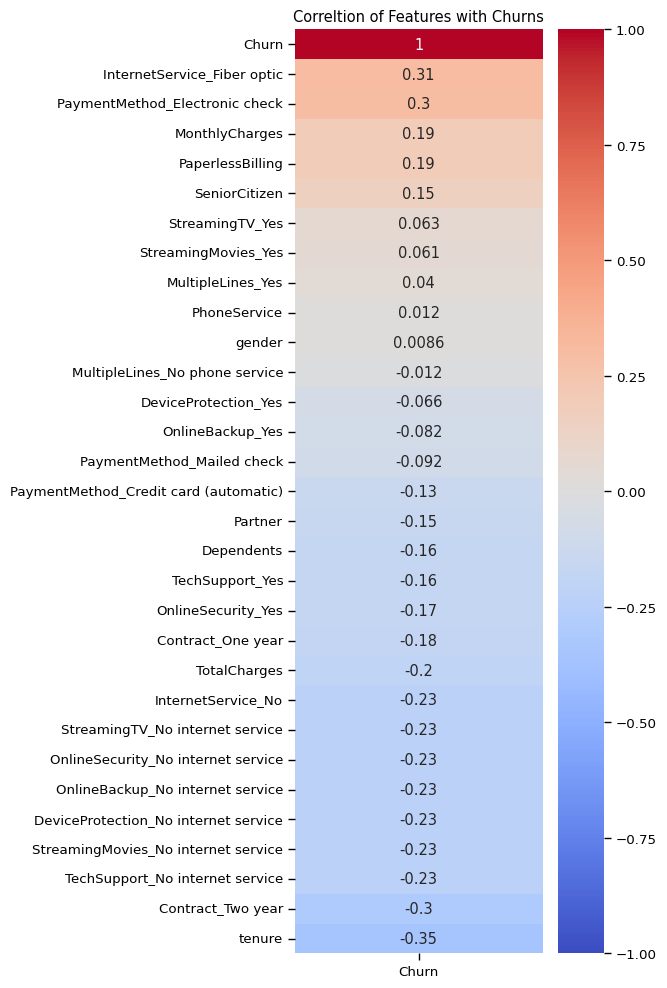

In [110]:
corr_matrix = df.corr(numeric_only = True)
churn_corr = corr_matrix[['Churn']].sort_values(by = "Churn", ascending = False)
print(churn_corr)

plt.figure(figsize = (4,12))
sns.heatmap(churn_corr, annot = True, cmap = 'coolwarm',vmin = -1, vmax = 1)
plt.title("Correltion of Features with Churns")
plt.show()

Positive Value (higher value - more likely to churn)

Negative Value (lower value - less likely to churn)

### Step 4: Exploratory Data Analysis & Visualization

In [111]:
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objects as go
g_labels = ['Male', 'Female']
c_labels = ['No', 'Yes']
fig = make_subplots(rows=1, cols=2, specs=[[{'type':'domain'}, {'type':'domain'}]])
fig.add_trace(go.Pie(labels=g_labels, values=df['gender'].value_counts(), name="Gender"),
              1, 1)
fig.add_trace(go.Pie(labels=c_labels, values=df['Churn'].value_counts(), name="Churn"),
              1, 2)

fig.update_traces(hole=.4, hoverinfo="label+percent+name", textfont_size=16)

fig.update_layout(
    title_text="Gender and Churn Distributions",

    annotations=[dict(text='Gender', x=0.16, y=0.5, font_size=20, showarrow=False),
                 dict(text='Churn', x=0.84, y=0.5, font_size=20, showarrow=False)])
fig.show()

- 26.5 % of customers switched to another firm.
- Customers are 49.5 % female and 50.5 % male.

In [112]:
fig = go.Figure()

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [965, 992, 219, 240],
  name = 'DSL',
))

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [889, 910, 664, 633],
  name = 'Fiber optic',
))

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [690, 717, 56, 57],
  name = 'No Internet',
))

fig.update_layout(title_text="<b>Churn Distribution w.r.t. Internet Service and Gender</b>")

fig.show()

- A lot of customers choose the Fiber optic service and it's also evident that the customers who use Fiber optic have high churn rate, this might suggest a dissatisfaction with this type of internet service.
- Customers having DSL service are majority in number and have less churn rate compared to Fibre optic service.

C:\Users\yuan_\AppData\Local\Temp\ipykernel_13812\964309717.py:2: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.


C:\Users\yuan_\AppData\Local\Temp\ipykernel_13812\964309717.py:4: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




Text(0.5, 1.0, 'Distribution of monthly charges by churn')

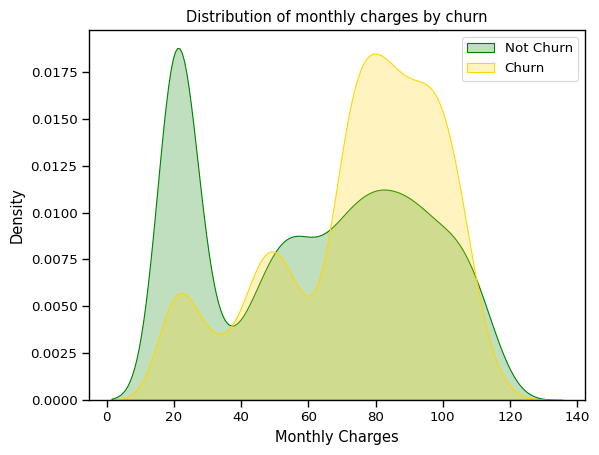

In [113]:
sns.set_context("paper",font_scale=1.1)
ax = sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 0) ],
                color="Green",shade =True)
ax = sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 1) ],
                ax =ax, color="Gold",shade = True)
ax.legend(["Not Churn","Churn"],loc='upper right')
ax.set_ylabel('Density')
ax.set_xlabel('Monthly Charges')
ax.set_title('Distribution of monthly charges by churn')

- Customers with higher Monthly Charges are also more likely to churn

In [ ]:
fig = px.box(df, x='Churn', y = 'tenure')

fig.update_yaxes(title_text='Tenure (Months)', row=1, col=1)
fig.update_xaxes(title_text='Churn', row=1, col=1)
fig.update_layout(autosize=True, width=750, height=600,
    title_font=dict(size=25, family='Courier'),
    title='<b>Tenure vs Churn</b>',
)

fig.show()

- New customers are more likely to churn

### Step 5: Investigating the multicolinearity between features

In [115]:
df['No_internet_service'] = (
    df['OnlineSecurity_No internet service'] |
    df['OnlineBackup_No internet service'] |
    df['DeviceProtection_No internet service'] |
    df['TechSupport_No internet service'] |
    df['StreamingTV_No internet service'] |
    df['StreamingMovies_No internet service']
).astype(int)

drop_cols = [col for col in df.columns if 'No internet service' in col]
df = df.drop(columns=drop_cols)

if 'MultipleLines_No phone service' in df.columns:
    df['No_phone_service'] = df['MultipleLines_No phone service'].astype(int)
    df = df.drop(columns=['MultipleLines_No phone service'])

In [116]:
X = df.drop(columns=['Churn'])
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [117]:

from statsmodels.stats.outliers_influence import variance_inflation_factor
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

print(vif_data)

c:\Users\yuan_\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning:

divide by zero encountered in scalar divide



                                  feature          VIF
11                     InternetService_No          inf
23                    No_internet_service          inf
5                            PhoneService  1775.269077
7                          MonthlyCharges   866.089640
10            InternetService_Fiber optic   148.500814
24                       No_phone_service    60.934666
17                    StreamingMovies_Yes    24.156394
16                        StreamingTV_Yes    24.080019
8                            TotalCharges    10.811490
4                                  tenure     7.584453
9                       MultipleLines_Yes     7.289761
14                   DeviceProtection_Yes     6.924754
13                       OnlineBackup_Yes     6.796678
15                        TechSupport_Yes     6.476508
12                     OnlineSecurity_Yes     6.338349
19                      Contract_Two year     2.652328
21         PaymentMethod_Electronic check     1.976032
22        

- There's multicolinearity between features.
- To solve the problem, drop some features or use regularization method such as Ridge or Lasso regression

### Step 5: Build Machine Learning Data Models

Churn is determined as positive.

In churn prediction, recall is usually important. Because:
- False Positive: Predict a customer will churn, but they stay -> Waste retention resources
- False Negative: Predict a customer will stay, but they churn -> Miss the chance to retain customers and lose them
- Missing churners(FN) usually cost more than wrongly targeting a loyal customer

Priorities:
1. If retention resources are cheap -> prioritize recall to catch every possible churner
2. If retention resources are expensive -> balance precison and recall using f1 score or precision-recall trade_off
3. If business want to rank churn risk -> use ROC-AUC to evaluate the model

Algorithms Used:
To build a robust and high-performing churn prediction system, I decided to use the following ensemble learning algorithms:
1. LightGBM:
- Optimized gradient boosting framework with faster training speed and lower memory usage.
- Uses leaf-wise tree growth for better accuracy.
- Scales efficiently for larger datasets and production deployment.
- Performs well in imbalanced classification problems.

2. Random Forest:
- Reduces variance through bagging and decision tree aggregation.
- Handles nonlinear relationships and feature interactions effectively.
- Provides interpretable feature importance rankings.

3. XGBoost:
- Gradient boosting framework that sequentially corrects errors from previous trees.
- Highly effective for structured data.
- Supports regularization to prevent overfitting.
- Often achieves strong ROC-AUC performance in churn prediction tasks.

In [ ]:
from sklearn.model_selection import train_test_split

In [119]:
X = df.drop(columns = ["Churn"])
y = df['Churn']

In [120]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

THRESHOLD = 0.3

In [121]:
# LightGBM

In [122]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
import time

In [123]:
lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

start_train = time.time()
lgbm.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

start_pred = time.time()
proba = lgbm.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

print(classification_report(y_test, y_pred, digits=3))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1496, number of negative: 4138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000662 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
⏱ Training time: 0.85 seconds
⏱ Prediction time: 0.0206 seconds
              precision    recall  f1-score   support

           0      0.920     0.685     0.785      1036
           1      0.488     0.834     0.616       373

    accuracy                          0.725      1409
   macro avg      0.704     0.760     0.701      1409
weighted avg      0.805     0.

In [124]:
proba = lgbm.predict_proba(X_test)[:, 1]

print("Threshold tuning for LightGBM")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for LightGBM
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.473   0.866   0.612   
0.3     0.488   0.834   0.616   
0.35    0.506   0.812   0.623   
0.4     0.520   0.786   0.625   
0.45    0.534   0.743   0.621   
0.5     0.551   0.713   0.621   


In [125]:
# Random Forest Classifier

In [126]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,roc_curve


In [127]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1
 )
rf.fit(X_train, y_train)

proba = rf.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)

print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.899     0.781     0.836      1036
           1      0.554     0.756     0.639       373

    accuracy                          0.774      1409
   macro avg      0.726     0.768     0.738      1409
weighted avg      0.808     0.774     0.784      1409



In [128]:
proba = rf.predict_proba(X_test)[:, 1]

print("Threshold tuning for RandomForest")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for RandomForest
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.518   0.818   0.634   
0.3     0.554   0.756   0.639   
0.35    0.579   0.686   0.628   
0.4     0.597   0.603   0.600   
0.45    0.625   0.536   0.577   
0.5     0.643   0.453   0.531   


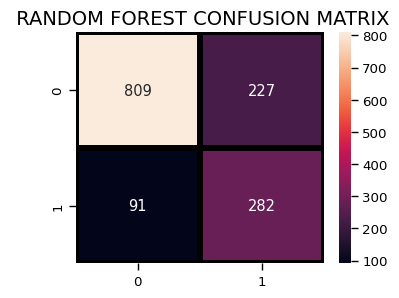

In [129]:
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred),
                annot=True,fmt = "d",linecolor="k",linewidths=3)
    
plt.title(" RANDOM FOREST CONFUSION MATRIX",fontsize=14)
plt.show()

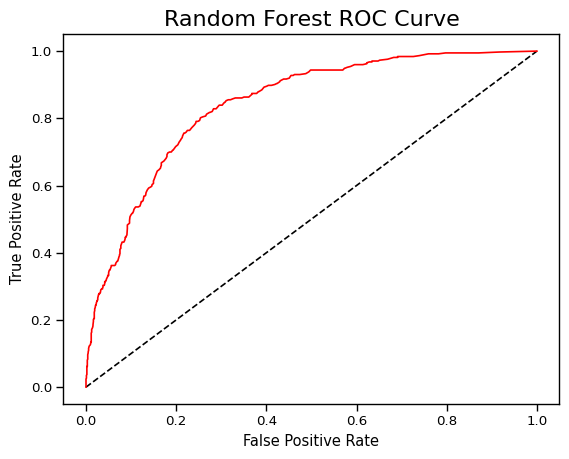

In [130]:
y_rfpred_prob = rf.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, thresholds = roc_curve(y_test, y_rfpred_prob)
plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr_rf, tpr_rf, label='Random Forest',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve',fontsize=16)
plt.show();

In [131]:
# XGBoost Classifier

In [132]:
from xgboost import XGBClassifier

In [ ]:
scale_pos_weight = (y_train == 0).sum()/(y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators = 500,
    learning_rate = 0.05,
    max_depth = 6,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42,
    n_jobs = -1,
    scale_pos_weight = scale_pos_weight,
    eval_metric = 'logloss'
)

start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

start_pred = time.time()
proba = xgb.predict_proba(X_test)[:,1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time()-start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

print(classification_report(y_test, y_pred, digits = 3))


⏱ Training time: 0.80 seconds
⏱ Prediction time: 0.0134 seconds
              precision    recall  f1-score   support

           0      0.921     0.683     0.784      1036
           1      0.487     0.836     0.616       373

    accuracy                          0.724      1409
   macro avg      0.704     0.760     0.700      1409
weighted avg      0.806     0.724     0.740      1409



In [134]:
proba = xgb.predict_proba(X_test)[:,1]
print("Threshold tuning for XGBoost")
print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")

for thresh in [0.25,0.30,0.35,0.40,0.45,0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label = 1)
    rec = recall_score(y_test, preds,pos_label=1)
    f1 = f1_score(y_test, preds,pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for XGBoost
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.471   0.863   0.610   
0.3     0.487   0.836   0.616   
0.35    0.501   0.812   0.620   
0.4     0.528   0.796   0.635   
0.45    0.544   0.753   0.631   
0.5     0.555   0.708   0.622   


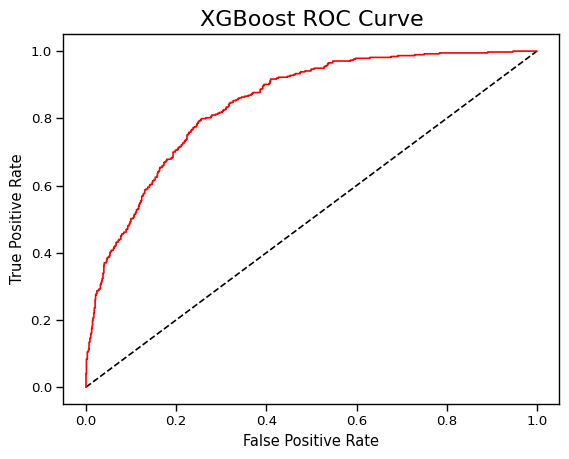

In [135]:

fpr_rf, tpr_rf, thresholds = roc_curve(y_test, proba)
plt.plot([0, 1], [0, 1], 'k--' )
plt.plot(fpr_rf, tpr_rf, label='Random Forest',color = "r")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve',fontsize=16)
plt.show();

### Step 6: Hyperparameter Tuning and Experiment Tracking

Compared the above model algorithms, I eventually choose XGBoost. This is because it gives a decent recall and faster to train.

In [136]:
import optuna

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),
        "eval_metric": "logloss"
    }

    model = XGBClassifier(**params)
    model.fit(X_train,y_train)
    proba - model.predict_proba(X_test)[:,1]
    y_pred = (proba >= THRESHOLD).astype(int)
    return recall_score(y_test, y_pred, pos_label = 1)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best Params:", study.best_params)
print("Best Recall:", study.best_value)

[I 2026-02-22 12:53:01,315] A new study created in memory with name: no-name-37695b6d-f86f-40e8-827e-467b9d750461
[I 2026-02-22 12:53:01,767] Trial 0 finished with value: 0.8364611260053619 and parameters: {'n_estimators': 475, 'learning_rate': 0.19594974168814597, 'max_depth': 8, 'subsample': 0.9680651393965964, 'colsample_bytree': 0.523363719714962, 'min_child_weight': 5, 'gamma': 1.5096898101229557, 'reg_alpha': 2.6491729720333783, 'reg_lambda': 0.682466805521526}. Best is trial 0 with value: 0.8364611260053619.
[I 2026-02-22 12:53:02,610] Trial 1 finished with value: 0.8364611260053619 and parameters: {'n_estimators': 594, 'learning_rate': 0.10297334681031615, 'max_depth': 8, 'subsample': 0.5201752885764519, 'colsample_bytree': 0.8907226685338836, 'min_child_weight': 6, 'gamma': 1.4562595061720385, 'reg_alpha': 2.4830999377035607, 'reg_lambda': 3.1479085699375164}. Best is trial 0 with value: 0.8364611260053619.
[I 2026-02-22 12:53:02,842] Trial 2 finished with value: 0.83646112600

Best Params: {'n_estimators': 475, 'learning_rate': 0.19594974168814597, 'max_depth': 8, 'subsample': 0.9680651393965964, 'colsample_bytree': 0.523363719714962, 'min_child_weight': 5, 'gamma': 1.5096898101229557, 'reg_alpha': 2.6491729720333783, 'reg_lambda': 0.682466805521526}
Best Recall: 0.8364611260053619


In [137]:
scale_pos_weight = (y_train == 0).sum()/(y_train == 1).sum()

best_params = study.best_params
best_params.update({
    "random_state": 42,
    "n_jobs": -1,
    "scale_pos_weight": scale_pos_weight,
    "eval_metric": "logloss"
})

xgb = XGBClassifier(**best_params)

start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

start_pred = time.time()
proba = xgb.predict_proba(X_test)[:,1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

print(classification_report(y_test, y_pred, digits=3))

⏱ Training time: 0.23 seconds
⏱ Prediction time: 0.0070 seconds
              precision    recall  f1-score   support

           0      0.949     0.590     0.727      1036
           1      0.444     0.912     0.598       373

    accuracy                          0.675      1409
   macro avg      0.697     0.751     0.662      1409
weighted avg      0.815     0.675     0.693      1409



In [138]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import roc_auc_score
import os
from pathlib import Path


project_root = Path(os.getcwd()).parent
tracking_path = project_root / "Churn_Prediction"
mlflow.set_tracking_uri(tracking_path.as_uri())
mlflow.set_experiment("Telco Churn - XGBoost")


with mlflow.start_run():
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    best_params = study.best_params
    best_params.update({
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": scale_pos_weight,
        "eval_metric": "logloss"
    })

    mlflow.log_params(best_params)
    start_train = time.time()
    xgb = XGBClassifier(**best_params)
    xgb.fit(X_train, y_train)
    train_time = time.time() - start_train
    mlflow.log_metric("train_time", train_time)

    start_pred = time.time()
    proba = xgb.predict_proba(X_test)[:,1]
    y_pred = (proba >= THRESHOLD).astype(int)
    pred_time = time.time() - start_pred
    mlflow.log_metric("pred_time", pred_time)

    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred,pos_label=1)
    auc = roc_auc_score(y_test, proba)

    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", auc)

    mlflow.xgboost.log_model(xgb,"model")
    print(classification_report(y_test, y_pred, digits = 3))



Traceback (most recent call last):
  File "c:\Users\yuan_\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\yuan_\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\yuan_\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\yuan_\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 16

              precision    recall  f1-score   support

           0      0.949     0.590     0.727      1036
           1      0.444     0.912     0.598       373

    accuracy                          0.675      1409
   macro avg      0.697     0.751     0.662      1409
weighted avg      0.815     0.675     0.693      1409



The tuned XGBoost Model maximizes recall for churners:

- Recall (Class 1): 0.912 -> Very high; the model successfully identifies most customers who are likely to churn.
- Precision (Class 1): 0.444 -> Relatively low; many loyal customers are incorrectly flagged as churners.
- F1 (Class 1): 0.598 -> Slightly lower than the untuned LightGBM model at balanced thresholds due to the significant drop in precision.


Model Interpretation:

The final model is highly effective at capturing almost all churners, which is ideal for businesses running aggressive retention strategies where the cost of outreach (e.g., emails, discounts, support calls) is relatively low and the cost of losing a customer (customer lifetime value loss) is high.Missing a churner (False Negative) is more expensive than targeting a loyal customer (False Positive). Although precision decreases, the trade-off is acceptable when retention interventions are inexpensive and scalable. This model prioritizes minimizing churn-related revenue loss over optimizing targeting efficiency.